## Lung Nodule Segmentation – Baseline Training (LIDC patches)
### This notebook trains a 2D U‑Net segmentation model on preprocessed lung nodule patches derived from the LIDC‑IDRI dataset.<br>
Key steps:

- Load pre-extracted 2D CT patches and nodule masks
- Create patient‑level train/validation/test splits
- Build PyTorch Datasets and DataLoaders
- Define a U‑Net segmentation model
- Train the model (Dice + BCE loss) with validation monitoring
- Plot training/validation curves and evaluate on the held‑out test set

This notebook corresponds to the “Model Training Procedure” and “Evaluation on Standard‑Dose CT” stages in our project proposal.

### Load preprocessed LIDC patch dataset

We do not load raw DICOM CT scans here. Instead, we use the output of our preprocessing pipeline:

* patches/ – 2D CT image patches (e.g. 128×128) centered on nodules
* masks/ – binary segmentation masks for the same patches
* patch_meta.csv – one row per patch with patient_id, nodule_id, slice_idx, and filenames

Using precomputed patches keeps the training notebook lightweight and avoids heavy I/O and preprocessing on Kaggle’s free GPU.

In [1]:
import os
import pandas as pd

os.listdir('/kaggle/input/datasets/ibgphimakara/')
DATA_ROOT = "/kaggle/input/datasets/ibgphimakara/lidc-nodule-patches-small/lidc_patches_small-V2.0"
PROC_DIR = os.path.join(DATA_ROOT, "lidc_patches_small")
PATCH_DIR = os.path.join(PROC_DIR, "patches")
MASK_DIR = os.path.join(PROC_DIR, "masks")

print("PROC_DIR:", PROC_DIR)
print("Num patch files:", len(os.listdir(PATCH_DIR)))
print("Num mask files:", len(os.listdir(MASK_DIR)))

meta_path = os.path.join(PROC_DIR, "patch_meta.csv")
meta_df = pd.read_csv(meta_path)
print("Meta rows:", len(meta_df))
print(meta_df.head())

PROC_DIR: /kaggle/input/datasets/ibgphimakara/lidc-nodule-patches-small/lidc_patches_small-V2.0/lidc_patches_small
Num patch files: 502
Num mask files: 502
Meta rows: 502
       patient_id  nodule_id  slice_idx                patch_file  \
0  LIDC-IDRI-0011          0          2  LIDC-IDRI-0011_n0_z2.npy   
1  LIDC-IDRI-0011          1          1  LIDC-IDRI-0011_n1_z1.npy   
2  LIDC-IDRI-0011          2          1  LIDC-IDRI-0011_n2_z1.npy   
3  LIDC-IDRI-0011          3          1  LIDC-IDRI-0011_n3_z1.npy   
4  LIDC-IDRI-0011          4          1  LIDC-IDRI-0011_n4_z1.npy   

                  mask_file  
0  LIDC-IDRI-0011_n0_z2.npy  
1  LIDC-IDRI-0011_n1_z1.npy  
2  LIDC-IDRI-0011_n2_z1.npy  
3  LIDC-IDRI-0011_n3_z1.npy  
4  LIDC-IDRI-0011_n4_z1.npy  


### Train / validation / test splits (patient‑level)

We split the data at the patient level, not at the patch or slice level.

Rationale:

* Avoid data leakage: patches from the same patient must not appear in both train and test.
* Match the proposal’s requirement for patient‑level separation of training, validation, and test sets.

Procedure:

1. List all unique patient_id values in patch_meta.csv.
2. Randomly split patients into 70% train, 15% validation, 15% test with a fixed random seed.
3. Filter patch_meta into three DataFrames accordingly.

The resulting splits define which patches are used to fit the model, tune hyperparameters, and evaluate final performance.

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

# Unique patients
patients = sorted(meta_df["patient_id"].unique())
print("Unique patients:", len(patients))

# Fixed seed for reproducibility
rng = np.random.RandomState(42)

train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=rng, shuffle=True)
val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=rng, shuffle=True)

print("Train patients:", len(train_p))
print("Val patients:", len(val_p))
print("Test patients:", len(test_p))

def filter_by_patients(df, plist):
    return df[df["patient_id"].isin(plist)].reset_index(drop=True)

train_df = filter_by_patients(meta_df, train_p)
val_df   = filter_by_patients(meta_df, val_p)
test_df  = filter_by_patients(meta_df, test_p)

for name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, "patches:", len(df_))

Unique patients: 158
Train patients: 110
Val patients: 24
Test patients: 24
train patches: 346
val patches: 75
test patches: 81


#### Saving the splits

In [3]:
OUTPUT_DIR = "/kaggle/working"
train_df.to_csv(os.path.join(OUTPUT_DIR, "train_meta.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_meta.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_meta.csv"), index=False)

### PyTorch Dataset and DataLoader

This section wraps the NumPy patch files into a PyTorch‑friendly interface.
Together, these classes implement the “2D patch cropping + augmentation” part of our methodology while keeping the training loop clean.
> Note that num_workers=0 is used here to avoid multiprocessing warnings.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torchvision.transforms.functional as TF

class LIDCPatchDataset(Dataset):
    def __init__(self, meta_df, patch_dir, mask_dir, train=True):
        self.meta_df = meta_df
        self.patch_dir = patch_dir
        self.mask_dir = mask_dir
        self.train = train

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        fname = row["patch_file"]

        img = np.load(os.path.join(self.patch_dir, fname)).astype(np.float32)
        msk = np.load(os.path.join(self.mask_dir, fname)).astype(np.float32)

        # Add channel dimension: (H, W) -> (1, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        msk = torch.from_numpy(msk).unsqueeze(0)

        if self.train:
            # Simple geometric augmentations
            if torch.rand(1) < 0.5:
                img = TF.hflip(img)
                msk = TF.hflip(msk)
            if torch.rand(1) < 0.5:
                img = TF.vflip(img)
                msk = TF.vflip(msk)

        return img, msk

BATCH_SIZE = 8

train_dataset = LIDCPatchDataset(train_df, PATCH_DIR, MASK_DIR, train=True)
val_dataset   = LIDCPatchDataset(val_df, PATCH_DIR, MASK_DIR, train=False)
test_dataset  = LIDCPatchDataset(test_df, PATCH_DIR, MASK_DIR, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

### U‑Net‑style segmentation model

We use a 2D U‑Net‑like encoder–decoder network as the baseline segmentation model.

Architecture highlights:

* Encoder (down path): repeated Conv → BN → ReLU blocks with max‑pooling to capture increasingly abstract features.
* Decoder (up path): transposed convolutions for upsampling plus skip connections that concatenate encoder features to recover spatial detail.
* Output layer: 1‑channel convolution producing a per‑pixel logit for the “nodule” class.

This model operates on 2D patches (1 × H × W) and outputs a mask of the same spatial size.

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.down1 = DoubleConv(in_ch, base)
        self.down2 = DoubleConv(base, base*2)
        self.down3 = DoubleConv(base*2, base*4)
        self.down4 = DoubleConv(base*4, base*8)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.conv4 = DoubleConv(base*16, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv3 = DoubleConv(base*8, base*4)

        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)

        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv1 = DoubleConv(base*2, base)

        self.outc = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool(c1)
        c2 = self.down2(p1)
        p2 = self.pool(c2)
        c3 = self.down3(p2)
        p3 = self.pool(c3)
        c4 = self.down4(p3)
        p4 = self.pool(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c4 = self.conv4(u4)

        u3 = self.up3(c4)
        u3 = torch.cat([u3, c3], dim=1)
        c3 = self.conv3(u3)

        u2 = self.up2(c3)
        u2 = torch.cat([u2, c2], dim=1)
        c2 = self.conv2(u2)

        u1 = self.up1(c2)
        u1 = torch.cat([u1, c1], dim=1)
        c1 = self.conv1(u1)

        logits = self.outc(c1)
        return logits

### Loss functions and optimizer

Training is supervised with binary masks and uses a combined loss:

* BCEWithLogitsLoss – pixel‑wise classification to handle foreground/background imbalance.
* Dice loss – region‑overlap loss encouraging good segmentation overlap and boundary quality.

Combined loss = BCE + Dice, to mix overlap‑based and pixel‑wise losses.

We use the Adam optimizer with a small learning rate (e.g. 1e-3), which is a standard choice for medical image segmentation.

In [6]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet2D(in_ch=1, out_ch=1, base=32).to(device)

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    # pred, target: (B,1,H,W) logits vs mask
    pred = torch.sigmoid(pred)
    num = 2 * (pred * target).sum(dim=(2,3)) + eps
    den = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    dice = num / den
    return 1 - dice.mean()

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
def dice_metric(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    num = 2 * (pred * target).sum(dim=(2,3)) + eps
    den = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    dice = num / den
    return dice.mean().item()

### Training loop (per‑epoch workflow)

Each epoch consists of two phases:

1. Training phase

* Set model.train() to enable gradient updates.
* For each batch from train_loader:
  
  - Move inputs and masks to the device.
  - Forward pass through U‑Net to get logits.
  - Compute combined loss (BCE + Dice).
  - Backpropagate (loss.backward()) and update parameters (optimizer.step()).
  
* Accumulate average training loss across all batches.

2. Validation phase

* Set model.eval() and disable gradients (torch.no_grad()).
* For each batch from val_loader:

    - Compute loss and segmentation predictions.
    - Compute a Dice metric on the validation set.
    - Track average validation loss and Dice for the epoch.

We print epoch‑level training loss, validation loss, and validation Dice. This supports early stopping, hyperparameter tuning, and meets the requirement to log training/validation performance.

In [8]:
from tqdm.auto import tqdm

best_val_dice = 0.0
EPOCHS = 60

train_losses = []
val_losses = []
val_dices = []

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False):
            imgs = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)
            loss = combined_loss(logits, masks)
            val_loss += loss.item() * imgs.size(0)
            val_dice += dice_metric(logits, masks) * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "/kaggle/working/best_unet_lidc.pth")
        print(f"  → New best model saved (val_dice={best_val_dice:.4f})")

Epoch 1 [train]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1 [val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: train_loss=1.5474 val_loss=1.4104 val_dice=0.0819
  → New best model saved (val_dice=0.0819)


Epoch 2 [train]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 2 [val]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 59 [val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 59: train_loss=0.1384 val_loss=0.2136 val_dice=0.8074


Epoch 60 [train]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 60 [val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 60: train_loss=0.1370 val_loss=0.2207 val_dice=0.7980


### Tracking and plotting training curves

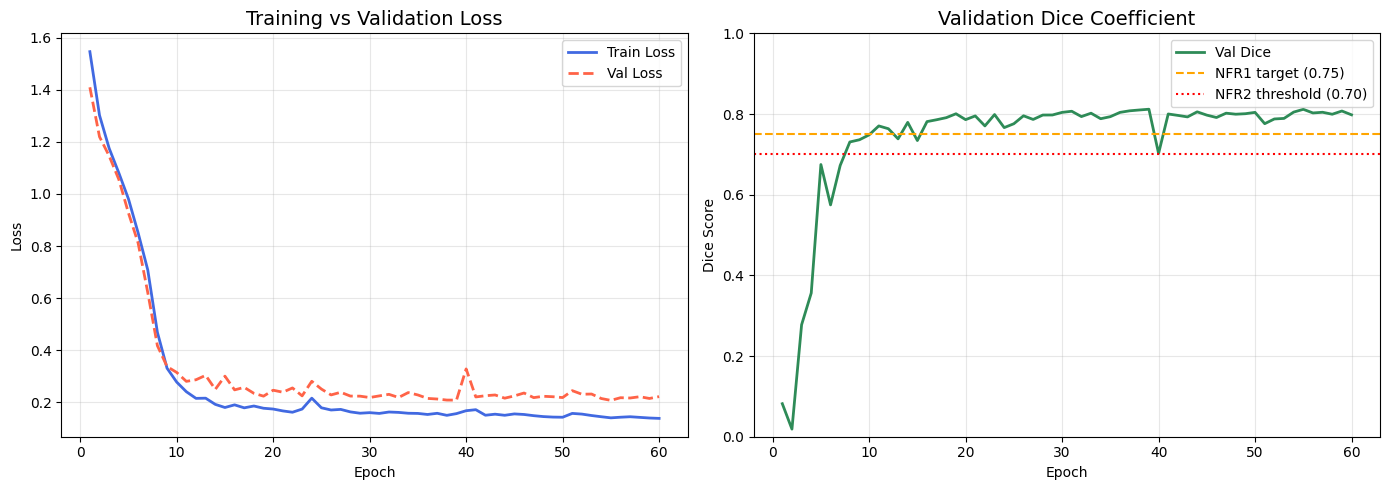

Best validation Dice: 0.8119


In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve ---
axes[0].plot(epochs_range, train_losses, label="Train Loss", color="royalblue", linewidth=2)
axes[0].plot(epochs_range, val_losses,   label="Val Loss",   color="tomato",    linewidth=2, linestyle="--")
axes[0].set_title("Training vs Validation Loss", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Dice curve ---
axes[1].plot(epochs_range, val_dices, label="Val Dice", color="seagreen", linewidth=2)
axes[1].axhline(y=0.75, color="orange", linestyle="--", linewidth=1.5, label="NFR1 target (0.75)")
axes[1].axhline(y=0.70, color="red",    linestyle=":",  linewidth=1.5, label="NFR2 threshold (0.70)")
axes[1].set_title("Validation Dice Coefficient", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

print("Best validation Dice:", round(best_val_dice, 4))

### Loading best model and test evaluation
Test set evaluation (standard‑dose CT)

We restore the best model checkpoint saved during training (highest validation Dice), then evaluate once on the held‑out test set:

* Compute metrics for each test patch:

    - Dice score
    - Intersection over Union (IoU)
    - Precision and recall (false positive / false negative balance)

* Report mean scores across all test samples.

In [10]:
# Reload best weights
best_path = "/kaggle/working/best_unet_lidc.pth"
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

from sklearn.metrics import precision_score, recall_score, jaccard_score
import numpy as np

all_dice = []
all_iou = []
all_prec = []
all_rec = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Test"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        # Flatten per batch
        for b in range(imgs.size(0)):
            p = preds[b].view(-1).cpu().numpy()
            t = masks[b].view(-1).cpu().numpy()

            # Dice
            inter = (p * t).sum()
            dice = (2*inter + 1e-6) / (p.sum() + t.sum() + 1e-6)
            iou = jaccard_score(t, p, zero_division=0)

            prec = precision_score(t, p, zero_division=0)
            rec  = recall_score(t, p, zero_division=0)

            all_dice.append(dice)
            all_iou.append(iou)
            all_prec.append(prec)
            all_rec.append(rec)

print("Test Dice mean:", np.mean(all_dice))
print("Test IoU  mean:", np.mean(all_iou))
print("Test Prec mean:", np.mean(all_prec))
print("Test Rec  mean:", np.mean(all_rec))

Test:   0%|          | 0/11 [00:00<?, ?it/s]

Test Dice mean: 0.8890963
Test IoU  mean: 0.8067143246206337
Test Prec mean: 0.8896787830270609
Test Rec  mean: 0.9028760652919853


### Export the trained model

To export the model, we typically save its `state_dict` (which contains the learned parameters) or the entire model object.
However, if you want to save the entire model (architecture + state_dict), you can do so directly. The `state_dict` of the best model was already saved during training to `/kaggle/working/best_unet_lidc.pth`.

In [11]:
import torch

# Option 1: Save the entire model (architecture + state_dict)
# This saves the model definition and its learned parameters.
# Load it simply with `model = torch.load(path)`
# However, it requires the class definition (UNet2D in this case) to be available when loading.

entire_model_path = "/kaggle/working/unet_model_full.pth"
torch.save(model, entire_model_path)
print(f"Entire model saved to {entire_model_path}")

# Option 2: Save only the model's state_dict (already done during training)
# This saves only the learned parameters. Load it by first instantiating the model
# and then `model.load_state_dict(torch.load(path))`

state_dict_path = "/kaggle/working/best_unet_lidc.pth" # This was already saved
print(f"Model state_dict already saved to {state_dict_path} during training.")

Entire model saved to /kaggle/working/unet_model_full.pth
Model state_dict already saved to /kaggle/working/best_unet_lidc.pth during training.


### Qualitative examples – segmentation overlays

Metrics alone can hide important failure modes. We therefore visualize a few representative test samples:

* CT patch (grayscale)
* Ground‑truth mask (binary)
* Model prediction overlaid as a contour on the CT patch

We include:

* Successful cases with good overlap
* Challenging cases (small nodules, low contrast, vessel‑adjacent nodules)

These overlays support the interpretability and error‑analysis objectives in the project proposal and are useful for the presentation.

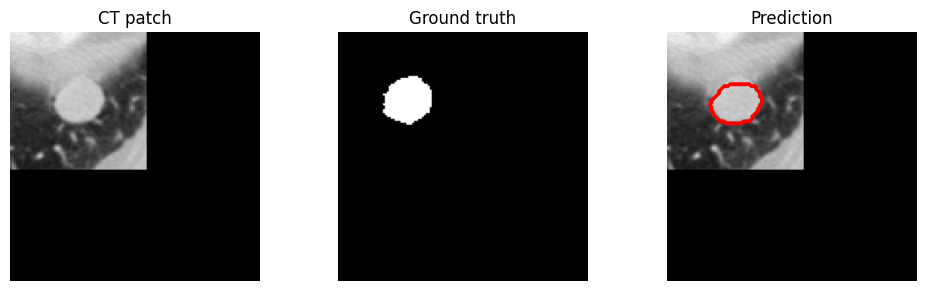

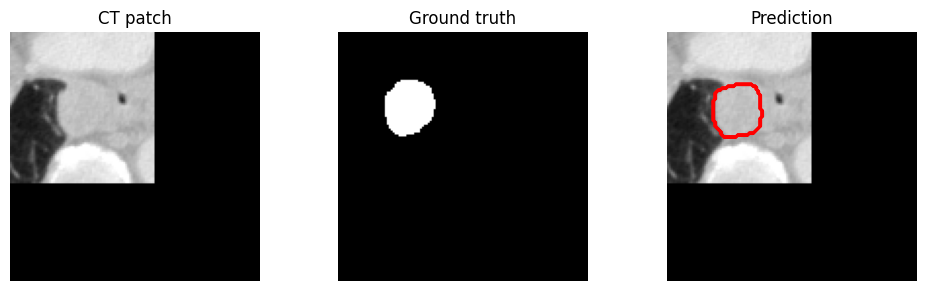

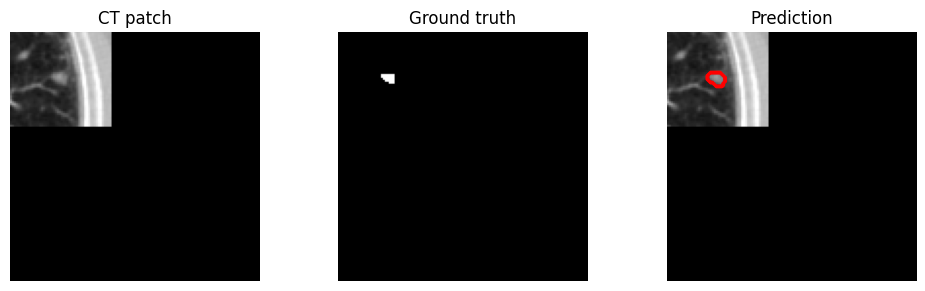

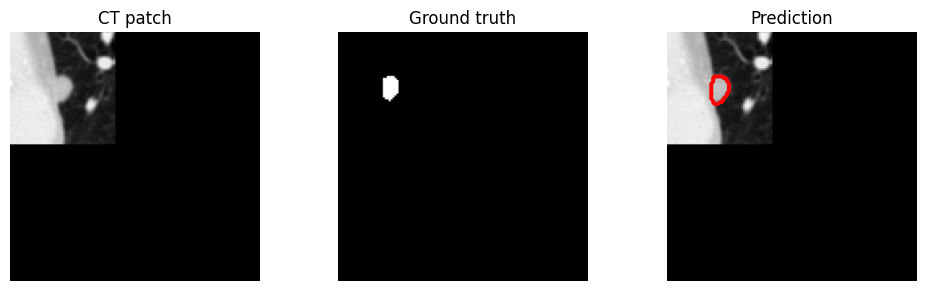

In [12]:
import matplotlib.pyplot as plt

model.eval()
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

for i in range(min(4, imgs.size(0))):
    img = imgs[i,0].cpu().numpy()
    gt  = masks[i,0].cpu().numpy()
    pr  = preds[i,0].cpu().numpy()

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("CT patch"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("Ground truth"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img, cmap="gray"); plt.contour(pr, colors="r"); plt.title("Prediction"); plt.axis("off")
    plt.tight_layout()
    plt.show()